# LIBRARY

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter
from collections import defaultdict


In [34]:
from imblearn.under_sampling import TomekLinks
from imblearn.over_sampling import SMOTE

In [35]:
import numpy as np
import scipy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from scikitplot.metrics import plot_roc
from scikitplot.metrics import plot_precision_recall
from sklearn.tree._tree import TREE_LEAF
from sklearn.tree import plot_tree, DecisionTreeRegressor
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
import numpy as np
from sklearn.ensemble import RandomForestClassifier

In [36]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

In [37]:
from imblearn.pipeline import Pipeline          # ← key fix
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

## SVM

In [38]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.svm import LinearSVC
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.calibration import CalibratedClassifierCV  # ← needed for predict_proba
import numpy as np

class LinearSVMRandomSearch(BaseEstimator, ClassifierMixin):
    def __init__(self, n_iter=400, n_splits=10, random_state=0):
        self.n_iter       = n_iter
        self.n_splits     = n_splits
        self.random_state = random_state

        self.best_model_  = None
        self.best_params_ = None
        self.best_score_  = None
        self.y_score_     = None
        self.info_        = None

    def fit(self, X, y):

        # ── LinearSVC valid combinations ──────────────────────────────────────
        # penalty l1 → only works with loss=squared_hinge + dual=False
        # penalty l2 → works with both loss options
        # dual=True  → recommended when n_samples > n_features
        # dual=False → recommended when n_features > n_samples

        param_list = [
            # l2 + hinge (standard SVM loss)
            {
                'C':            [0.01, 0.1, 1, 10, 100],
                'penalty':      ['l2'],
                'loss':         ['hinge'],
                'max_iter':     [500, 1000,2000],
                #'class_weight': ['balanced'],
            },
            # l1 + squared_hinge (l1 only works with squared_hinge + dual=False)
            {
                'C':            [0.01, 0.1, 1, 10, 100],
                'penalty':      ['l1','l2'],
                'loss':         ['squared_hinge'],
                'max_iter':     [500, 1000,2000],
                #'class_weight': ['balanced'],
            },
        ]

        random_search = RandomizedSearchCV(
            LinearSVC(),
            param_distributions=param_list,
            cv=KFold(n_splits=self.n_splits, shuffle=True,random_state=self.random_state),
            scoring='f1_weighted',
            n_jobs=-1,
            refit=True,
            n_iter=self.n_iter,
            random_state=self.random_state
        )
        random_search.fit(X, y)

        self.best_params_ = random_search.best_params_
        self.best_score_  = random_search.best_score_

        # ── Wrap with CalibratedClassifierCV to enable predict_proba ──────────
        # LinearSVC has no predict_proba natively — calibration adds it
        self.best_model_ = CalibratedClassifierCV(
            LinearSVC(**self.best_params_, random_state=self.random_state),
            cv=5
        )
        self.best_model_.fit(X, y)

        self.info_ = {
            'best_params':   self.best_params_,
            'best_cv_score': self.best_score_,
            'n_features':    self.best_model_.n_features_in_,
            'classes':       self.best_model_.classes_,
            'n_classes':     len(self.best_model_.classes_),
            'cv_results':    random_search.cv_results_,
        }

        print("="*55)
        print("LINEAR SVM — MULTICLASS TRAINING SUMMARY")
        print("="*55)
        print(f"  Best params    : {self.best_params_}")
        print(f"  Best CV score  : {self.best_score_:.4f}")
        print(f"  Classes found  : {self.info_['classes']}")
        print(f"  n classes      : {self.info_['n_classes']}")
        print(f"  Features used  : {self.info_['n_features']}")
        print(f"  penalty        : {self.best_params_['penalty']}")
        print(f"  loss           : {self.best_params_['loss']}")
        print(f"  C              : {self.best_params_['C']}")
        print("="*55)

        return self

    def predict(self, X):
        return self.best_model_.predict(X)

    def predict_proba(self, X):
        # CalibratedClassifierCV enables this — returns (n_samples, n_classes)
        self.y_score_ = self.best_model_.predict_proba(X)
        return self.y_score_




## NON LINEAR SVM

In [39]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV, KFold
import numpy as np

class NonLinearSVMRandomSearch(BaseEstimator, ClassifierMixin):
    def __init__(self, n_iter=400, n_splits=10, random_state=0):
        self.n_iter       = n_iter
        self.n_splits     = n_splits
        self.random_state = random_state

        self.best_model_  = None
        self.best_params_ = None
        self.best_score_  = None
        self.y_score_     = None
        self.info_        = None

    def fit(self, X, y):

        # ── Valid kernel/param combinations ───────────────────────────────────
        # gamma  → only meaningful for rbf, poly, sigmoid (not linear)
        # degree → only meaningful for poly kernel
        # coef0  → only meaningful for poly and sigmoid kernels
        # → list of dicts keeps combinations clean and valid

        param_list = [
            # RBF kernel — most commonly used non-linear kernel
            {
                'C':            [0.01, 0.1, 1, 10, 100],
                'kernel':       ['rbf'],
                'gamma':        ['scale', 'auto', 0.001, 0.01, 0.1, 1],
                'class_weight': ['balanced'],
            },
            # Polynomial kernel — good for image/text data
            {
                'C':            [0.01, 0.1, 1, 10, 100],
                'kernel':       ['poly'],
                'gamma':        ['scale', 'auto', 0.001, 0.01, 0.1, 1],
                'degree':       [2, 3, 4, 5],       # polynomial degree
                'coef0':        [0, 0.1, 0.5, 1],   # independent term
                'class_weight': ['balanced'],
            },
            # Sigmoid kernel — similar to neural network activation
            {
                'C':            [0.01, 0.1, 1, 10, 100],
                'kernel':       ['sigmoid'],
                'gamma':        ['scale', 'auto', 0.001, 0.01, 0.1, 1],
                'coef0':        [0, 0.1, 0.5, 1],
                'class_weight': ['balanced'],
            },
        ]

        random_search = RandomizedSearchCV(
            SVC(probability=True, random_state=self.random_state),
            param_distributions=param_list,
            cv=KFold(n_splits=self.n_splits, shuffle=True,random_state=self.random_state),
            scoring='f1_weighted',
            n_jobs=-1,
            refit=True,
            n_iter=self.n_iter,
            random_state=self.random_state
        )
        random_search.fit(X, y)

        self.best_params_ = random_search.best_params_
        self.best_score_  = random_search.best_score_

        # ── Retrain best model on full data ───────────────────────────────────
        self.best_model_ = SVC(
            **self.best_params_,
            probability=True,
            random_state=self.random_state
        )
        self.best_model_.fit(X, y)

        self.info_ = {
            'best_params':    self.best_params_,
            'best_cv_score':  self.best_score_,
            'n_features':     self.best_model_.n_features_in_,
            'classes':        self.best_model_.classes_,
            'n_classes':      len(self.best_model_.classes_),
            'n_support_':     self.best_model_.n_support_,   # support vectors per class
            'support_':       self.best_model_.support_,     # indices of support vectors
            'cv_results':     random_search.cv_results_,
        }

        print("="*55)
        print("NON-LINEAR SVM — MULTICLASS TRAINING SUMMARY")
        print("="*55)
        print(f"  Best params       : {self.best_params_}")
        print(f"  Best CV score     : {self.best_score_:.4f}")
        print(f"  Classes found     : {self.info_['classes']}")
        print(f"  n classes         : {self.info_['n_classes']}")
        print(f"  Features used     : {self.info_['n_features']}")
        print(f"  Kernel            : {self.best_params_['kernel']}")
        print(f"  C                 : {self.best_params_['C']}")
        print(f"  Support vectors   : {self.info_['n_support_']} per class")
        print(f"  Total support vec : {self.info_['n_support_'].sum()}")
        print("="*55)

        return self

    def predict(self, X):
        return self.best_model_.predict(X)

    def predict_proba(self, X):
        # SVC with probability=True supports this natively
        # no CalibratedClassifierCV needed unlike LinearSVC
        self.y_score_ = self.best_model_.predict_proba(X)
        return self.y_score_



# READ DATAFRAME

In [40]:
file_path = "../1.DATASET/CMI_FINAL_OD_SS.csv"
df=pd.read_csv(file_path)

In [41]:
df

,id,Basic_Demos-Age,Basic_Demos-Sex,Physical-BMI,Physical-Height,Physical-Weight,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,sii
0,0,-1.467073,-0.822843,-0.561893,-1.343231,-1.008221,-0.250870,-0.956432,-0.428812,-0.942872,-0.939966,-0.992591,-0.818300,-0.947148,-0.726336,-1.265162,-0.874740,-0.859871,2.0
1,1,-0.338700,-0.822843,-1.221382,-1.083906,-1.128018,0.630346,-0.657546,-0.367405,1.285851,-0.939966,-1.033298,-0.804797,-0.932563,-1.053662,-1.265162,-1.226847,-1.273565,0.0
2,2,-0.056607,1.215298,-0.614950,0.018225,-0.389269,-0.232187,1.018179,-1.466511,0.790579,0.280796,-0.662859,-0.199213,-0.347769,-0.314411,0.512640,-0.355318,-0.148634,0.0
3,3,-0.338700,-0.822843,-0.233502,-0.046607,-0.239523,-0.577200,0.665395,-0.367405,-0.695236,0.280796,-0.456268,0.057750,-0.249394,-0.126332,0.512640,-0.283279,0.116846,1.0
4,4,2.200139,1.215298,-0.315811,-0.224763,-0.375806,0.577087,-0.304761,1.210082,-0.198377,0.280796,3.297345,1.538145,-0.330005,-0.314411,0.512640,0.009328,-0.148634,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8377,8455,-0.902887,1.215298,-0.735189,-1.334155,-1.060626,-0.281071,-0.789840,-0.392148,-0.695236,-2.160727,-1.012064,-0.820639,-0.817405,-1.103413,-1.265162,-1.004029,-0.941197,0.0
8378,8456,-0.056607,1.215298,-0.463799,-0.029751,-0.341052,-0.490946,-0.613448,-1.251639,-1.685780,0.280796,0.067523,-0.439950,-0.015430,-0.823890,-1.265162,-0.581341,-0.582047,1.0
8379,8457,-0.056607,1.215298,5.021847,-0.881633,1.293649,-0.249437,0.533101,-0.627980,0.542943,1.501557,-0.388344,-0.705917,1.239140,0.886735,0.512640,0.152734,-0.682526,0.0
8380,8458,1.353859,1.215298,0.742981,0.963464,0.974332,0.395292,-0.481153,1.201246,1.038215,-0.939966,0.058376,-0.447250,1.092211,0.366529,0.512640,1.420549,0.963516,2.0


In [42]:
column2drop = ['id']
df.drop(column2drop, axis=1, inplace=True)
attributes = [col for col in df.columns if col != 'sii']
X = df[attributes].values
y = np.array(df['sii'])


# Data Preparation

In [43]:
X.shape

(8382, 17)

In [44]:
np.unique(y, return_counts=True)

(array([0., 1., 2., 3.]), array([5794, 1567,  936,   85], dtype=int64))

In [45]:
Counter(y)

Counter({0.0: 5794, 1.0: 1567, 2.0: 936, 3.0: 85})

In [46]:
ctr = Counter(y)
ctr

Counter({0.0: 5794, 1.0: 1567, 2.0: 936, 3.0: 85})

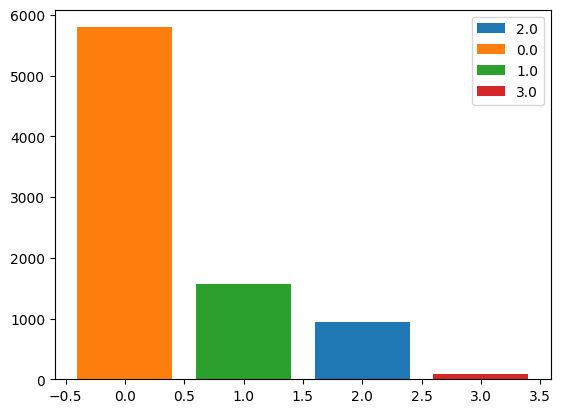

In [47]:
plt.bar(ctr.keys(), ctr.values(), label=ctr.keys(), color=['tab:blue', 'tab:orange','tab:green','tab:red'])
plt.legend()
plt.show()

## Data Partitioning

In [48]:
from sklearn.model_selection import train_test_split, cross_val_score 

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100, stratify=y)

In [50]:
X_train.shape

(5867, 17)

In [51]:
np.unique(y_train, return_counts=True), np.unique(y_test, return_counts=True)

((array([0., 1., 2., 3.]), array([4056, 1097,  655,   59], dtype=int64)),
 (array([0., 1., 2., 3.]), array([1738,  470,  281,   26], dtype=int64)))

In [52]:
np.max(np.unique(y_train, return_counts=True)[1])/len(X_train)

0.6913243565706494

# LINEAR SVM

## PIPELINE

### Imbalance

In [53]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [54]:
over_dic={1:2500,2:2000,3:1500}
under_dic={0:3000}

In [55]:
over = SMOTE(random_state=42, sampling_strategy=over_dic)
under = TomekLinks(sampling_strategy='majority')

### training

In [56]:
from imblearn.pipeline import Pipeline

pipeline = Pipeline([
    ('over',  over),
    ('under', under),
    ('clf',   LinearSVMRandomSearch(n_iter=400, n_splits=10, random_state=0))
])


pipeline.fit(X_train, y_train)
y_pred  = pipeline.predict(X_test)
y_score = pipeline.predict_proba(X_test) 

c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 45 is smaller than n_iter=400. Running 45 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


LINEAR SVM — MULTICLASS TRAINING SUMMARY
  Best params    : {'penalty': 'l2', 'max_iter': 500, 'loss': 'squared_hinge', 'C': 1}
  Best CV score  : 0.3828
  Classes found  : [0. 1. 2. 3.]
  n classes      : 4
  Features used  : 17
  penalty        : l2
  loss           : squared_hinge
  C              : 1


In [57]:
info = pipeline['clf'].info_

print(info['best_params'])
print(info['n_classes'])
print(info['best_cv_score'])

{'penalty': 'l2', 'max_iter': 500, 'loss': 'squared_hinge', 'C': 1}
4
0.3827901413285982


In [58]:
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.6063618290258449
F1-score [0.77850877 0.1627907  0.17659138 0.05797101]
              precision    recall  f1-score   support

         0.0       0.74      0.82      0.78      1738
         1.0       0.26      0.12      0.16       470
         2.0       0.21      0.15      0.18       281
         3.0       0.03      0.23      0.06        26

    accuracy                           0.61      2515
   macro avg       0.31      0.33      0.29      2515
weighted avg       0.59      0.61      0.59      2515



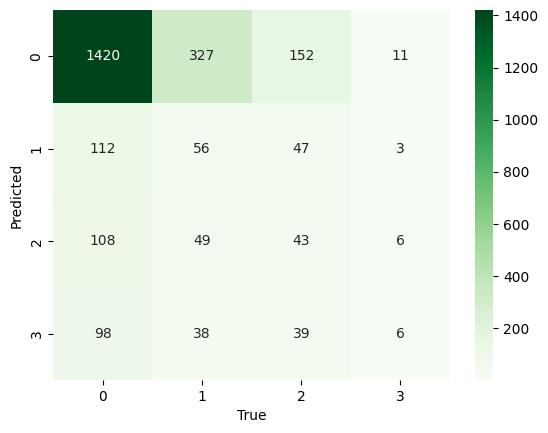

In [59]:
cf = confusion_matrix(y_pred,y_test)
sns.heatmap(cf, annot=True, cmap="Greens",fmt='g')
plt.xlabel("True")
plt.ylabel("Predicted")
plt.show()

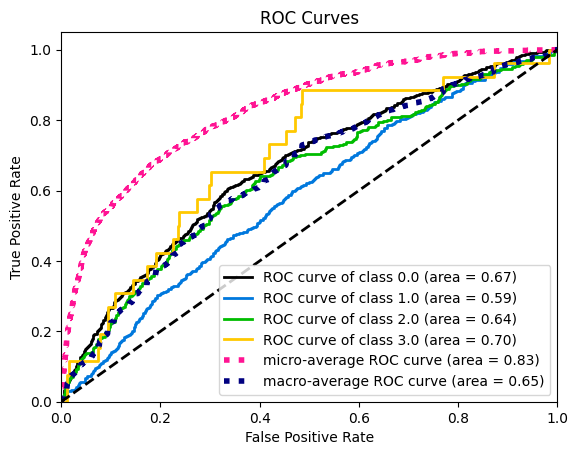

In [60]:
# roc
plot_roc(y_test, y_score)
plt.show()

# NON LINEAR SVM

## PIPELINE

### Imbalance

In [61]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [62]:
over_dic={1:2500,2:2000,3:1500}
under_dic={0:3000}

In [63]:
over = SMOTE(random_state=42, sampling_strategy=over_dic)
under = TomekLinks(sampling_strategy='majority')

### training

In [ ]:
from imblearn.pipeline import Pipeline

pipeline = Pipeline([
    ('over',  over),
    ('under', under),
    ('clf',   NonLinearSVMRandomSearch(n_iter=400, n_splits=10, random_state=0))
])


pipeline.fit(X_train, y_train)
y_pred  = pipeline.predict(X_test)
y_score = pipeline.predict_proba(X_test) 

In [ ]:
info = pipeline['clf'].info_

print(info['best_params'])
print(info['n_classes'])
print(info['best_cv_score'])

In [ ]:
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

In [ ]:
cf = confusion_matrix(y_pred,y_test)
sns.heatmap(cf, annot=True, cmap="Greens",fmt='g')
plt.xlabel("True")
plt.ylabel("Predicted")
plt.show()

In [ ]:
# roc
plot_roc(y_test, y_score)
plt.show()